# SVM: Linear

In [1]:
from IPython.display import SVG, display

Support Vector Machine
: A classification algorithm that finds the **best boundary** to separate **two classes** ($-1,1$) by maximizing the distance to the closest observations.

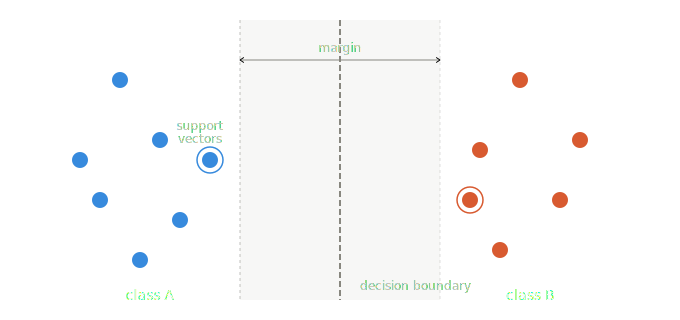

In [ ]:
display(SVG(filename="../data/SVM/svc_explained.svg"))

- Observations that are included within the dashed lines are called as **support vectors**. 

| Description | Formula |
|-------------|---------|
| Equation for a line in two dimensions | $(\beta_0 + \beta_1 x_1 + \beta_2 x_2) = 0$ |
| Equation for a hyperplane | $(\beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p) = 0$ |
| Observations above the hyperplane | $(\beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p) > 0$ |
| Observations below the hyperplane | $(\beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p) < 0$ |

$$y_i \in \{-1,1\}, i=1,...n$$
- Observations below the hyperplane are classified as $y=(-1)$.
- Observations above the hyperplane are classified as $y=(+1)$.
- Since $y$ is either $\{-1, 1\}$, $y(\beta_0 + \beta_1x_1 + ... \beta_px_p)$ always stays as positive.
- As long as the two groups are nearly separable, this statement holds: $y(\beta_0 + \beta_1x_1 + ... \beta_px_p) \geq 0$.
  - This can be redefined with a _margin_, $M$, such that: $y(\beta_0 + \beta_1x_1 + ... \beta_px_p) \geq M$.
  - $M$ is the distance of the line to the closest observation. 

## Linearly Separable

### Maximum Margin Classifier
$$\begin{aligned}
\max_{\beta_0,\beta_1,\ldots,\beta_p,\; M}\quad & M \\
\text{subject to}\quad 
& \left\{
\begin{aligned}
\sum_{j=1}^{p} \beta_j^{2} &= 1, \\
y_i\left(\beta_0 + \beta_1 x_{i1} + \cdots + \beta_p x_{ip}\right) &\ge M,
\quad i=1,\ldots,n.
\end{aligned}
\right.
\end{aligned}$$
$$ \text{where } M > 0 \text{ is the margin, } p \text{ is the number of } x \text{-variables, and}$$
$$j \text{ is the index for each feature}.$$
$$y_i \in {-1,1}, i=1,...,n$$
- $y(\beta_0 + \beta_1x_1 + ... \beta_px_p) \geq M$ implies no errors.
- $\max_{\beta_0,\beta_1,\ldots,\beta_p,\; M}$ implies to find the hyperplane that gives the **largest possible margin $M$** between the two classes.
  - These coefficients, $\beta$, should give the largerst possible margin $M$.
  - Noramlization of $\beta$ controls the margin width.  


Normalization
: Fixing the scale of the $\beta$ vector so that it has a specific length. 
: $$ \| \beta \| = \sqrt{\beta^2_1+\beta^2_2+...+\beta^2_p}$$
- By notating $\sum_{j=1}^{p} \beta_j^{2} = 1$, the coefficient scale is fixed to $1$. Can also be written as $\|\beta\| = 1$.

:::{tip} SVC Constraint
$$y(\beta_0 + \beta_1x_1 + ... \beta_px_p) \geq M$$
**Every observation** must be at least distance $M$ from the decision boundary, and on the correct side. 
:::

- Ensure that the constraint on $\beta$ is met by dividing by the norm.

$$\frac{1}{\|\beta\|}y_i(\beta_0 + \beta_1x_1 + ... \beta_px_p) \geq M$$
$$\left\|
\frac{1}{\|\beta\|}
\begin{pmatrix}
\beta_1\\
\beta_2\\
\vdots\\
\beta_3
\end{pmatrix}
\right\|
=
\frac{1}{\|\beta\|}
\left\|
\begin{pmatrix}
\beta_1\\
\beta_2\\
\vdots\\
\beta_3
\end{pmatrix}
\right\|
=
\frac{1}{\|\beta\|}\,\|\beta\|
= 1$$

This proves that when you _normalize_ $\beta$, the result has length $1$. 

$$y_i(\beta_0 + \beta_1x_1 + ... \beta_px_p) \geq M\|\beta\|$$
- $\beta$ can be multiplied by any positive constant, $c$, because both sides will scale equally. The actual values of $\beta$ don't uniquely matter, only their ratios do.

### Formula Rearrangements
$$\frac{1}{\|\beta\|}y_i(\beta_0 + \beta_1x_1 + ... \beta_px_p) \geq M$$
- This is the original form that maximizes margin $M$, while keeping $\beta$ a unit vector. It is hard to optimize because of the $\|\beta\|=1$ constraint. 

$$\min_{\beta_j, j=1,\ldots,p} \frac{1}{M} \quad \text{subject to} \quad y_i(\beta_0 + x_i^T\beta) \geq M, \quad \|\beta\| = 1$$
- _Subject to_: "Under the condition that..." Hence, Find the $\beta$ that makes $\|\beta^2\|$ as small as possible, but only consider solutions where every training point is correctly classified with margin $\geq 1$.
- Maimizing $M$ is the same thing as minimizing $\frac{1}{M}$. 

$$\min_{\beta_j, j=1,\ldots,p} \frac{1}{M} \quad \text{subject to} \quad y_i(\beta_0 + x_i^T\beta) \geq M\|\beta\|$$
- Drop the $\|\beta\|$ constraint. Absorb the unit norm constraitn into the inequality, and $\beta$ can be any scale. 
- If we assume $M=\frac{1}{\|\beta\|}$, 
$$\min_{\beta_j, j=1,\ldots,p} \|\beta\|^2 \quad \text{subject to} \quad y_i(\beta_0 + x_i^T\beta) \geq 1$$
- Minimizing $\|\beta\|$ is the same thing as minimizing $\|\beta\|^2$. If $\|\beta\|$ is minimized at some $\|\beta*\|$, then $\|\beta\|^2$ is also minimized at the exact point at $\beta*$. 
- Final optimization for **quadratic optimization problem** with a linear constant:
$$\min_{\beta_j, j=1,\ldots,p} \frac{1}{2}\|\beta\|^2 \quad \text{subject to} \quad y_i(\beta_0 + x_i^T\beta) \geq 1$$

- To minimizie $\|\beta\|^2$ as a constraint, the Lagragian trick merges the objective and constraint into a single expression. 
$$L = \frac{1}{2}\|\beta\|^2 - \sum_{i=1}^{N} \alpha_i\left[y_i(\beta_0 + x_i^T\beta) - 1\right]$$

| Term | Expression | Meaning |
|------|-----------|---------|
| First term | ½‖β‖² | The original objective you want to minimize |
| Second term | ∑αᵢ[yᵢ(β₀ + xᵢᵀβ) - 1] | Penalizes violations of the constraint |
| αᵢ | Lagrange multipliers | One per training point, weights that control how much each constraint matters |

$$L = \frac{1}{2}(\beta_1^2 + \beta_2^2 + \cdots + \beta_p^2) - \sum_{i=1}^{N} \alpha_i\left[y_i(\beta_0 + x_i^T\beta) - 1\right]$$
- Set derivatives with respect to $\beta_j, \beta_o$ to zero (to find a minimum of a function):
$$\beta_j = \sum_{i=1}^{N} \alpha_i y_i x_{ij}; \qquad j = 1, \ldots, p$$
$$0 = \sum_{i=1}^{N} \alpha_i y_i$$
- Writing $\beta$ in vector notation avoiding index $j$:
$$\beta_j = \sum_{i=1}^{N} \alpha_i y_i x_{ij}; \qquad j = 1, \ldots, p$$
$$\Leftrightarrow \beta = \sum_{i=1}^{N} \alpha_i y_i x_i$$
- Thus, we know $\beta$ is a linear combination of the observations. 

Lagrange Multiplier
: A variable that convers a constrained optimization problem into an unconstriained one. 
: $$L = f(x) - \alpha \cdot g(x)$$
: $$f(x) = \text{Function to minimize}, g(x) = \text{constraint}, \alpha = \text{Lagrange multiplier}$$
: $\alpha$ measures how much the constraint is **pushing back** against the objective. The larger $\alpha$ is, more influeential the constraint is.

- Only the observations on the boundary have $\alpha_i$ > 0.
- Observations in the interior space have $\alpha_i = 0$. 

Kuhn-Tucker Condition
: Rules that the **optimal solution** must satisfy when you have an optimization problem with inequality constraints. 
: To optimize $\max_xf(x)$, $\text{subject to } g(x) \leq 0$,
: If $x*$ is a local optimum, subject to regularity conditions, then there exist a constant multiplier $\alpha_i$ such that,
: $$g(x*) \leq 0$$
: $$ \alpha_i \geq 0$$
: $$\alpha_i \cdot g(x*) = 0 \qquad \forall i$$

#### Complementary Slackness
$$\alpha_i \big[\, y_i(\beta_0 + x_i^{\top}\beta) - 1 \,\big] = 0, \qquad \forall i$$
- Stemming from $\alpha_i \cdot g(x*) = 0$, _complementary_ so that the two terms complement each other to make zero. When one is zero, the other must be nonzero. 
- A point $x_i$ is on the boundary if $\big[\, y_i(\beta_0 + x_i^{\top}\beta) - 1 \,\big] = 0$.
- Also, if $\alpha_i > 0$, then $x_i$ is on the boundary. If $x_i$ is not on the boundary, then $a_i = 0$.

### Beta Optimization
$$\begin{align}
\beta &= \sum_{i=1}^{N} \alpha_i y_i x_i \\
      &= \sum_{i \in S} \alpha_i y_i x_i \\
      & \text{where } S = \text{set of support vectors.}
\end{align}$$
Hence, this proves that estimation of $\beta$ is only dependent on support vectors.

## Not Linearly Separable

```{figure} ../data/SVM/nonlinear.png
:align: center

- In cases like this, two classes are not _completely separable_.

$$\operatorname{maximize}_{\beta_{ij}, \epsilon_i, i=1,\ldots,n; j=1,\ldots,p} \quad M$$

$$\text{subject to} \begin{cases} \displaystyle\sum_{j=1}^{p} \beta_j^2 = 1 \\[10pt] y_i(\beta_0 + \beta_1 x_{i1} + \cdots + \beta_p x_{ip}) \geq M(1 - \epsilon_i) \\[10pt] \epsilon_i \geq 0; \quad \displaystyle\sum_{i=1}^{n} \epsilon_i \leq C \end{cases}$$

- Non-linearly separable classess can be managed with some errors. This is the **slack variables**, or $\epsilon_i$.
- All observations between the margin, and the separating hyperplane, and all misclassified observations (on the other side of the separating hyperplane) have a positive $\epsilon_i > 0$. 
- Errors, $\epsilon_i$, of the correctly classified observations before the margin is $0$. 

### Error Limit
- The sum of $\epsilon_i$ cannot exceed $C$.
- $C$ is the tuning parameter; the _cost_ parameter.
  - Larger $C$ value allows for more error and have larger margins. Also correspond to more support vectors because more observations lie within the larger margins. 

### Prediction
$$\text{sign}(\beta_0 + \beta_1 x_i + ... + \beta_p x_p)$$

| Score | sign() | Predicted class |
|---|---|---|
| Positive | +1 | Class +1 |
| Negative | -1 | Class -1 |
| Zero | 0 | On the boundary |

- How a new observation is being classified is decided by _which side_ of the hyperplane the observation falls on.
- Mathematically, the sign of the estimated value, $\text{sign}(\hat{f(x)})$, determines whether the observation is classified as $+1$ or $-1$, where:
$$\hat{f}(x) = \hat{\beta_0} + \hat{\beta_1}x_1 +... + \hat{\beta_p}x_p$$
$$\hat{f}(x) = \hat{\beta_0} + \sum_{i \in S} \hat{\alpha_i}y_i<x,x_1>$$
- where $<.. , ..>$ is the inner dot product, $\hat{\alpha_i} > 0, i=1,...n$ is the estimated coefficients arising during optimization. 
$$K(x, x_i) = \sum_{j=1}^p x_{ij}x_{i'j}$$
- The dot product measures similarity between two observations, where $x_i$ is an observation from training data and $x$ is an observation from test data. 

---
# SVM: Kernels

```{figure} ../data/SVM/nonlinear2.png
:align: center

- Add quadratic derived variables, so that the linear separation becomes possible in an expanded space, but it is still nonlinear in the original space. 
- In the original space (Assume we have $x_1, x_2$), classes may not be separable. 
- Add new features like $x_1^2, x_2^2, x_1x_2$ and now we're in the high dimensional, expanded space. In this sapce, since higher dimensions have sparse data, a linear boundary (hyperplane) can separate the classes. 
- But when you project that boundary back to the original space, it looks _nonlinear_. 

$$\max_{\beta_0,\{\beta_{j1},\beta_{j2}\}_{j=1}^p,\{\epsilon_i\}_{i=1}^n,\, M}\; M
\quad \text{subject to} \quad
\left\{
\begin{aligned}
\sum_{j=1}^{p}\left(\beta_{j1}^{2}+\beta_{j2}^{2}\right) &= 1, \\
y_i\left(\beta_0+\sum_{j=1}^{p}\beta_{j1}x_{ij}+\sum_{j=1}^{p}\beta_{j2}x_{ij}^{2}\right) &\ge M(1-\epsilon_i),
\quad i=1,\ldots,n, \\
\epsilon_i &\ge 0,\quad i=1,\ldots,n, \\
\sum_{i=1}^{n}\epsilon_i &\le C.
\end{aligned}
\right.$$

- Adding nonlinearities in $x$. 
- The original feature space has $p$ variables, but expanded feature spaces have $2*p$ variables. 
- SVM is a _linear_ method in the expanded features space. 
- SVM accommodates nonlinearity in the original feature space. 

Kernels
: A function that computes the similarity between two points in a higher dimensional space, without actually going there. Instead of expanding to high dimensions (which can be slow), directly computes what the dot product in that high dimensional space would have been. 
: $$K(x_i, x_j) = \langle \phi(x_i), \phi(x_j) \rangle$$
: $$\text{where } w = \text{ transformation to high dimensions.}$$

- How kernels expand feature space is not obvious.

### Predictions
- From $\hat{\beta} = \sum_{i \in S} \hat{a_i}y_ix_u$, the predicted value is:

$$
\begin{aligned}
\hat{f}(x) &= \hat{\beta}_0 + \hat{\beta}^t x \\
&= \hat{\beta}_0 + \left(\sum_{i \in S} \hat{\alpha}_i\, y_i\, x_i\right)^tx
\end{aligned}
$$

| Symbol | Type | Meaning |
|--------|------|---------|
| $x_i$  | Vector | Training data (feature vector for observation $i$) |
| $x$  | Vector | A new vector that we want to predict |
| $y_i$  | Scalar | Class label ($+1$ or $-1$) |
| $\alpha_i$ | Scalar | Lagrange multipliers arising during optimization |
| $S$ | Vector | Set of support vectors |

Can be re-written as:
$$\hat{f}(x) = \hat{\beta}_0 + \sum_{i \in S} \hat{\alpha}_i\, y_i \,\langle x, x_i \rangle$$
$$\langle x_i, x_{i'} \rangle = \sum_{j=1}^{p} x_{ij}\,x_{i'j}$$

> The solution depends only on the _inner_ product of the observations, not on the observations themselves.

#### Non-Linear Expansion
- Rather than adding quadratic terms to the $x$-variables, it is possible to expand the feature space as a function of the original $x$-variables.
$$\hat{f}(x) = \hat{\beta_0} + \sum_{i \in S} \hat{\alpha_i}y_i \space \langle h(x), h(x_i) \rangle $$
$$ \text{where } h(x) = \text{ derived variable}$$
$$h(x) = (h_i(x), h_2(x),...,h_{p_{new}}(x))$$

Can be re-written as:
$$
\begin{aligned}
\hat{f}(x) &= \hat{\beta}_0 + \sum_{i \in S} \hat{\alpha}_i\, y_i \,\langle h(x), h(x_i) \rangle \\
&= \hat{\beta}_0 + \sum_{i \in S} \hat{\alpha}_i\, y_i \, K(x, x_i)
\end{aligned}
$$
$$ \text{where } K = \text{ Kernel function}$$

#### Linear Kernel
$$K(x, x_i) = \sum_{j=1}^p x_{ij}x_{i'j}$$

- Referes to the **standard SVM** without any additional $x$-variables. 
- Has no additonal tuning parameters.
- Often preferred in text mining applications with $n$-gram variables. 
  - Sparse matrices and indicator variables.

#### Polynomial Kernel
$$K(x_i, x_{i'}) = \left(\beta_0 + \gamma \sum_{j=1}^{p} x_{ij}\,x_{i'j}\right)^{d}$$
$$ \text{where } d = \text{ Degree of polynomial}$$

- Tuning parameters: $\beta_0, \gamma_0, d \space (d > 0)$.
  - In practice, often set $\beta_0 = 0, d = 2 \text{ or } 3 \text{ and tune } \gamma \text{ and } C$

:::{dropdown} Polynomial Kernel Example
$$K(x_i, x_{i'}) = \left(\beta_0 + \gamma \sum_{j=1}^{p} x_{ij}\,x_{i'j}\right)^{d}$$
Set $\beta_0 = 1, \space \gamma = 1, \space d=2, \space p=2$

$$K(x, x') = \left(1 + \sum_{j=1}^{p} x_j x_j'\right)^d$$
And we know that $x, x'$ are undergoing dot product, we can make a substitution.
During training, both $x, x'$ are from training points, being compard to each other. This is how the model learns the support vectors and $\alpha$'s.
During prediction, $x$ is the new test point, and $x'$ is the support vector from training. 
$$\sum_{j=1}^{p} x_j x_j' = \langle x, x' \rangle$$
$$\langle x, x' \rangle = x_1x_1' + x_2x_2' + \cdots + x_px_p' = \sum_{j=1}^{p} x_j x_j'$$

\begin{align}
K(x, x') &= (1 + \langle x, x' \rangle)^2 \\
          &= (1 + x_1x_1' + x_2x_2')^2 \text{, since } p = 2 \text{, meaning there are two features.}\\
          &= 1 + 2x_1x_1' + 2x_2x_2' + (x_1x_1')^2 + (x_2x_2')^2 + 2x_1x_1'x_2x_2'
\end{align}

Now we enlarged the $x$-space with $6$ terms. 

From the list below, what higher dimensional space does the polynomial kernel implicitly map to?
The kernel generates following polynomial variables:
- $h_1(x) = 1$
- $h_2(x) = \sqrt{2}x_1$
- $h_3(x) = \sqrt{2}x_2$
- $h_4(x) = x_1^2$
- $h_5(x) = x_2^2$
- $h_6(x) = \sqrt{2}x_1x_2$

| Term in expansion | Written as $h(x) \cdot h(x')$ | So $h(x) =$ |
|---|---|---|
| $1$ | $1 \cdot 1$ | $h_1 = 1$ |
| $2x_1x_1'$ | $\sqrt{2}x_1 \cdot \sqrt{2}x_1'$ | $h_2 = \sqrt{2}x_1$ |
| $2x_2x_2'$ | $\sqrt{2}x_2 \cdot \sqrt{2}x_2'$ | $h_3 = \sqrt{2}x_2$ |
| $(x_1x_1')^2$ | $x_1^2 \cdot x_1'^2$ | $h_4 = x_1^2$ |
| $(x_2x_2')^2$ | $x_2^2 \cdot x_2'^2$ | $h_5 = x_2^2$ |
| $2x_1x_1'x_2x_2'$ | $\sqrt{2}x_1x_2 \cdot \sqrt{2}x_1'x_2'$ | $h_6 = \sqrt{2}x_1x_2$ |

:::

#### RBF Kernel
- Also called as _Gaussian Kernel_.
$$K(x_i, x_{i'}) = \exp\!\left( -\gamma \sum_{j=1}^{p} \left(x_{ij} - x_{i'j}\right)^2 \right)$$
- Tuning parameter: $\gamma > 0$.
  - $\gamma$ determines how fast the influence of neighboring observations on the classification of the test observation drops off as a function of distance. Larger $\gamma$ leads to a local fit. 
- $xi'$ is a test observation.
- When a test observation is very far from training observation, the exponent quickly becomes $0$. 
  - Training observations far from test observation contribute very little to classification. 
- Most popular choice. 
- Corresponds to an infinite number of $x$-variables. 

#### Sigmoid Kernel
$$K(x_i, x_{i'}) = \tanh\!\left(\beta_0 -\gamma \sum_{j=1}^{p} x_{ij}x_{i'j} \right)$$

```{figure} ../data/SVM/sigmoid.png
:align: center

- Tuning parameters: $\gamma > 0, \beta$.
- Not commonly used because of some undesirable theoretical properties. 

| Kernel | When to use |
|---|---|
| **Linear** | Data is already high dimensional (e.g. text, genomics), large datasets, when you suspect linear separability |
| **Polynomial** | When you believe feature interactions matter, image recognition |
| **RBF/Gaussian** | Default choice, when you have no prior knowledge, works well in most cases |
| **Sigmoid** | Rarely used, sometimes in neural network contexts |

:::{tip} Normalization
$$x_{\text{scaled}} = \frac{x-\bar{x}}{sd(x)}$$
- SVM is very sensitive to how variables are scaled. 
- As we know $K\langle x, x' \rangle = x_1x_1' + x_2x_2' + ...$, kernel and decision boundary depend on distances and dot products between the data points. 
- To make sure that each feature contribute fairly to distances and dot products, it is better to normalize the features.
:::

## Platt's Method
Platt Scaling
: A method to convert SVM's raw decision scores into probabilities. 
- Since logistic regression computes a probability which is rounded up or down for classification, SVM yield a score. 
  - Positive scores: $y=+1$ is more likely.
  - Negative scores: $y=-1$ is more likely.
$$\text{score} = \hat{f}(x) = \hat{\beta_0} + \sum_{i \in S} \hat{\alpha_i}y_iK(x, x_i)$$

### Converting Scores into Probabilities
- This is Platt's way of estimating probabilities based on the score.
- If a probability is needed, we can use logistic regression on the score:
$$\log \frac{p}{1-p} = \beta_0 + \beta_1 \hat{f}(x)$$
- The probabilities can be estimated as usual by solving for $p$. 

## Multi-Class SVM
- Typically, SVM only allows for two classes. 
- Can extend two-class classifiers:

##### 1. One vs. All
- More common.
- With $K$ classes, apply SVM once for each class.
  - Class $k$ vs. all remaining claases. 
- Each SVM classifier gives a score $f(x)$ for class $k$ (vs. all others.)
- Predict the class $k$ that has the highest score $f(x)$.

##### 2. One vs. One
- $k$ classes give ($k$ choose $2$) possible pairs.
- SVM is conducted on each pair.
- Keep track of which class wins each time.
- Predict the class with the most wins.

::::{grid} 2
:::{card}
:header: Usage 
- Works well with large feature numbers.
- Works well when number of features exceeds the number of observations.
- Memory efficient for prediction, because only support vectors are needed. 

:::
:::{card}
:header: Limitations 
- When the dataset is large, training time can be very long.
- For nonlinear kernels, you may encounter convergence problems.
- Does not work as well in the presence of a lot of noise variables.
- Probability estimates are ad-hoc.
- SVM is sensitive to scaling of $x$-variables. 
:::
::::

::::{grid} 1
:::{grid-item}
:class: text-center
{button}`Solution <../solution/SVM.pdf>`
::::